# TBCA — Text-Based Conjoint Analysis
## Empirical Proof-of-Concept: Amazon Laptop Reviews
**Paper**: *From Utility Theory to Algorithmic Choice* (Anastasiadis & Ampeliotis, 2026)

---
### Pipeline
1. Download dataset from Kaggle
2. Run ABSA (aspect extraction + sentiment scoring)
3. Prospect Theory debiasing
4. MAUT utility estimation (OLS → part-worth weights)
5. Softmax / MNL choice probabilities
6. Axiomatic consistency verification
7. Export tables + charts for paper

**Runtime**: GPU recommended (T4 free tier on Colab is sufficient)  
**Estimated time**: ~15–20 minutes (ABSA model download + inference)

# **Cell 1 — Install dependencies**
Run this first. Restart runtime if prompted.

In [1]:
# Cell 1 —  Install all required packages
!pip install -q -U transformers huggingface_hub
!pip install -q pandas numpy scikit-learn matplotlib seaborn tabulate kaggle

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 87.9 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4


#Cell 2 — Kaggle API setup
Before running this cell:

Go to kaggle.com → Your Profile → Settings → API → Create New Token
A file kaggle.json will download with your credentials
Upload it to Colab using the code below

In [2]:
import os
from google.colab import files

# Upload your kaggle.json
print('Upload your kaggle.json file:')
uploaded = files.upload()

# Place it in the correct directory
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle credentials configured.')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


## **Cell 3 — Download dataset**
Dataset: Amazon Laptop Review by Ashwini Shet
URL: https://www.kaggle.com/datasets/ashwinishet/amazon-laptop-review
~500 reviews with reviewText and overall (1–5 stars)

In [3]:
import pandas as pd
import numpy as np

# Download from Kaggle
!kaggle datasets download -d ashwinishet/amazon-laptop-review -p /content/data --unzip

# Load the CSV (filename may vary — list files first)
import glob
csv_files = glob.glob('/content/data/*.csv') + glob.glob('/content/data/*.json')
print('Files found:', csv_files)

# Load (adjust filename if needed)
try:
    df = pd.read_csv(csv_files[0])
except:
    df = pd.read_json(csv_files[0], lines=True)

print(f'\nDataset shape: {df.shape}')
print('Columns:', list(df.columns))
df.head(3)

Dataset URL: https://www.kaggle.com/datasets/ashwinishet/amazon-laptop-review
License(s): unknown
100% 36.5k/36.5k [00:00<00:00, 6.65MB/s]

Files found: ['/content/data/amazon_review.csv']

Dataset shape: (511, 3)
Columns: ['comments', 'rating', 'title']


,comments,rating,title
0,Very slow and not good 8gb ram according spee...,4.0,Very solow speed and hang laptop bad
1,Really hate the product. Its wastage of money....,1.0,Its a regret!!
2,The Product Worth it,5.0,Good Product


In [4]:
# ── Standardise column names ──────────────────────────────────────────────
# Map whatever columns exist to 'text' and 'rating'
# Common variants: 'reviewText'/'review_text'/'body', 'overall'/'rating'/'stars'

col_map = {}
for c in df.columns:
    cl = c.lower()
    if any(k in cl for k in ['review', 'text', 'body', 'comment']):
        col_map[c] = 'text'
    if any(k in cl for k in ['overall', 'rating', 'star', 'score']):
        col_map[c] = 'rating'

df = df.rename(columns=col_map)

# Keep only relevant columns; drop missing
df = df[['text', 'rating']].dropna()
df['text']   = df['text'].astype(str).str.strip()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['rating'])
df = df[df['text'].str.len() > 20]   # remove very short texts
df = df.reset_index(drop=True)

print(f'Clean dataset: {len(df)} reviews')
print(df['rating'].value_counts().sort_index())

Clean dataset: 413 reviews
rating
1.0    148
2.0     29
3.0     40
4.0     68
5.0    128
Name: count, dtype: int64


In [5]:
# ── Sample for manageable ABSA inference time ─────────────────────────────
# 200 reviews is sufficient for a proof-of-concept
# Increase to 500+ for a more robust paper result

N_SAMPLE = 200   # adjust as needed

# Stratified sample: preserve rating distribution
from sklearn.model_selection import train_test_split

if len(df) > N_SAMPLE:
    df_sample, _ = train_test_split(
        df, train_size=N_SAMPLE,
        stratify=df['rating'].clip(1, 5).astype(int),
        random_state=42
    )
    df_sample = df_sample.reset_index(drop=True)
else:
    df_sample = df.copy()

print(f'Working with {len(df_sample)} reviews')
print(df_sample['rating'].value_counts().sort_index())

Working with 200 reviews
rating
1.0    72
2.0    14
3.0    19
4.0    33
5.0    62
Name: count, dtype: int64


## **Cell 4 — ABSA: Aspect extraction + sentiment scoring**
Using PyABSA with the pretrained multilingual ATEPC checkpoint.
This model:

Extracts aspect terms (e.g. "battery", "screen", "performance") automatically
Assigns sentiment polarity: **Positive / Negative / Neutral**

Provides a confidence score
Theoretical link (paper Section 2.3):


---



Extracted aspects = MAUT attribute dimensions


---


Sentiment scores = empirical surrogates for part-worth utilities


---



In [ ]:
# Cell 4 — ABSA με HuggingFace pipeline (αντί PyABSA)
from transformers import pipeline

# Pretrained ABSA model — fine-tuned στο SemEval Laptop14 dataset
# Ακριβώς το dataset που αναφέρεται στο paper σου (Pontiki et al., 2016)
absa_model = pipeline(
    "text-classification",
    model="yangheng/deberta-v3-base-absa-v1.1",
    tokenizer="yangheng/deberta-v3-base-absa-v1.1",
    device=0 if device == 'cuda' else -1
)
print("ABSA model loaded.")

## **Cell 4b — ABSA inference (aspect prompting)**
For each review and each attribute, the model accepts input of the form aspect [SEP] review text and returns sentiment score

**sij∈[−1,+1]s_{ij} \in [-1, +1] sij​∈[−1,+1].**

The 5 attributes (battery life, display quality, performance, build quality, value for money) correspond to the dimensions **xix_i xi​ of MAUT (Eq. 10)**.

Result: 1000 aspect-sentiment observations.

In [7]:
# Cell 4b — ABSA inference με aspect prompting
# Η τεχνική: για κάθε review ρωτάμε το μοντέλο ξεχωριστά για κάθε attribute

ASPECT_QUERIES = {
    'battery_life':    ['battery', 'battery life', 'charge'],
    'display_quality': ['screen', 'display', 'resolution'],
    'performance':     ['performance', 'speed', 'processor'],
    'build_quality':   ['build quality', 'keyboard', 'design'],
    'value_for_money': ['price', 'value', 'worth the money'],
}

LABEL_TO_SCORE = {
    'positive': 1.0,
    'negative': -1.0,
    'neutral':   0.0
}

records = []

for idx, row in df_sample.iterrows():
    text = row['text']
    rating = row['rating']

    for attribute, aspect_terms in ASPECT_QUERIES.items():
        scores = []
        for aspect in aspect_terms:
            # Format: "[CLS] aspect [SEP] review text"
            input_text = f"{aspect} [SEP] {text[:400]}"
            try:
                result = absa_model(input_text, truncation=True, max_length=512)
                label = result[0]['label'].lower()
                conf  = result[0]['score']
                raw_score = LABEL_TO_SCORE.get(label, 0.0)
                scores.append(raw_score * conf)
            except:
                scores.append(0.0)

        # Average across aspect term variants
        final_score = float(np.mean(scores)) if scores else 0.0
        records.append({
            'review_idx': idx,
            'rating':     rating,
            'attribute':  attribute,
            'score':      final_score
        })

    if idx % 20 == 0:
        print(f'Processed {idx}/{len(df_sample)} reviews', end='\r')

df_absa = pd.DataFrame(records)
print(f'\nABSA complete. Shape: {df_absa.shape}')
df_absa.head(10)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



ABSA complete. Shape: (1000, 4)


,review_idx,rating,attribute,score
0,0,5.0,battery_life,0.958664
1,0,5.0,display_quality,0.985695
2,0,5.0,performance,0.983430
3,0,5.0,build_quality,0.988236
4,0,5.0,value_for_money,0.987082
5,1,4.0,battery_life,-0.795870
6,1,4.0,display_quality,-0.830655
7,1,4.0,performance,-0.813969
8,1,4.0,build_quality,-0.816506
9,1,4.0,value_for_money,-0.725008


In [8]:
# Cell 4c — Filtering unreliable scores
# We only keep scores with high confidence (|score| > 0.6)
# and avoid the "all positive/negative" problem

df_absa_filtered = df_absa[df_absa['score'].abs() > 0.6].copy()

# Check: how many reviews have at least 1 mapped aspect
reviews_with_aspects = df_absa_filtered['review_idx'].nunique()
print(f'Reviews με ≥1 reliable aspect: {reviews_with_aspects}/200')
print(f'Aspect mentions μετά filtering: {len(df_absa_filtered)}')
print(f'\nΚατανομή ανά attribute:')
print(df_absa_filtered['attribute'].value_counts())
print(f'\nΔείγμα:')
print(df_absa_filtered.head(10))

Reviews με ≥1 reliable aspect: 186/200
Aspect mentions μετά filtering: 886

Κατανομή ανά attribute:
attribute
display_quality    182
battery_life       178
build_quality      178
performance        177
value_for_money    171
Name: count, dtype: int64

Δείγμα:
   review_idx  rating        attribute     score
0           0     5.0     battery_life  0.958664
1           0     5.0  display_quality  0.985695
2           0     5.0      performance  0.983430
3           0     5.0    build_quality  0.988236
4           0     5.0  value_for_money  0.987082
5           1     4.0     battery_life -0.795870
6           1     4.0  display_quality -0.830655
7           1     4.0      performance -0.813969
8           1     4.0    build_quality -0.816506
9           1     4.0  value_for_money -0.725008


In [9]:
# ── Build feature matrix: one row per review, one column per attribute ─────
# Multiple mentions of the same attribute in one review → averaged

# Define ATTRIBUTES from ASPECT_QUERIES which is defined in a previous cell
ATTRIBUTES = list(ASPECT_QUERIES.keys())

df_absa_mapped = df_absa_filtered.copy()

# Pivot: mean sentiment score per review × attribute
pivot = df_absa_mapped.groupby(['review_idx', 'attribute'])['score'].mean().unstack(fill_value=0)

# Ensure all 5 attribute columns exist
for attr in ATTRIBUTES:
    if attr not in pivot.columns:
        pivot[attr] = 0.0
pivot = pivot[ATTRIBUTES]   # enforce column order

# Merge with ratings
ratings_series = df_sample['rating'].rename('rating')
df_features = pivot.join(ratings_series, how='inner')
df_features = df_features.dropna()

print(f'Feature matrix shape: {df_features.shape}')
print(f'Reviews with \u22651 mapped aspect: {len(df_features)}')
df_features.head()

Feature matrix shape: (186, 6)
Reviews with ≥1 mapped aspect: 186


,battery_life,display_quality,performance,build_quality,value_for_money,rating
0,0.958664,0.985695,0.983430,0.988236,0.987082,5.0
1,-0.795870,-0.830655,-0.813969,-0.816506,-0.725008,4.0
2,0.995038,0.995543,0.992159,0.991250,0.996788,4.0
3,-0.931073,-0.864163,-0.754550,-0.841724,-0.819473,3.0
5,0.906031,0.847591,0.804626,0.875051,0.876724,4.0


## **Cell 5 — Prospect Theory debiasing (Section 7.2)**
Parameters: **λ = 2.25, α = 0.88** (Tversky & Kahneman, 1992)

Corrects for:

Loss aversion bias: negative reviews over-represented in UGC
Diminishing sensitivity: extreme scores compressed toward center

In [10]:
LAMBDA = 2.25   # Tversky & Kahneman (1992)
ALPHA  = 0.88

def pt_debias(s):
    """Inverse PT correction: s ∈ [-1,+1] → debiased score."""
    if s == 0:
        return 0.0
    elif s > 0:
        return s ** ALPHA
    else:
        return -(abs(s) ** ALPHA) / LAMBDA

# Apply to each attribute column
X_raw    = df_features[ATTRIBUTES].values.copy()
X_debias = np.vectorize(pt_debias)(X_raw)

y = ((df_features['rating'].values - 1) / 4.0)   # normalise to [0,1]

print('Raw feature matrix (first 3 rows):')
print(pd.DataFrame(X_raw[:3], columns=ATTRIBUTES).round(3))
print('\nDebiased feature matrix (first 3 rows):')
print(pd.DataFrame(X_debias[:3], columns=ATTRIBUTES).round(3))

Raw feature matrix (first 3 rows):
   battery_life  display_quality  performance  build_quality  value_for_money
0         0.959            0.986        0.983          0.988            0.987
1        -0.796           -0.831       -0.814         -0.817           -0.725
2         0.995            0.996        0.992          0.991            0.997

Debiased feature matrix (first 3 rows):
   battery_life  display_quality  performance  build_quality  value_for_money
0         0.964            0.987        0.985          0.990            0.989
1        -0.364           -0.377       -0.371         -0.372           -0.335
2         0.996            0.996        0.993          0.992            0.997


## **Cell 6 — MAUT utility estimation (Section 6.3)**


Û(x) = Σᵢ ŵᵢ · ûᵢ(xᵢ) (Eq. 10 — MAUT additive form)
= W · φ(x) + b (Eq. 15 — neural linear layer)



---



We estimate weights via Ridge regression (OLS with L2 regularisation).

In [12]:
import numpy as np
from sklearn.linear_model import Ridge

# ── Bootstrap 95% CI for part-worth weights ──────────────────────────────
N_BOOT = 1000
np.random.seed(42)
n = len(X_debias)
boot_weights = np.zeros((N_BOOT, len(ATTRIBUTES)))

# OLS / Ridge regression on the full dataset to get overall w_debias_norm
ridge_raw    = Ridge(alpha=0.01, fit_intercept=True)
ridge_debias = Ridge(alpha=0.01, fit_intercept=True)

ridge_raw.fit(X_raw,    y)
ridge_debias.fit(X_debias, y)

w_raw    = ridge_raw.coef_
w_debias = ridge_debias.coef_

w_raw_norm    = np.abs(w_raw)    / np.abs(w_raw).sum()
w_debias_norm = np.abs(w_debias) / np.abs(w_debias).sum()

for b in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)
    Xb, yb = X_debias[idx], y[idx]
    ridge_b = Ridge(alpha=0.01)
    ridge_b.fit(Xb, yb)
    w_boot_coef = np.abs(ridge_b.coef_)
    boot_weights[b] = w_boot_coef / w_boot_coef.sum()

ci_lower = np.percentile(boot_weights, 2.5,  axis=0)
ci_upper = np.percentile(boot_weights, 97.5, axis=0)

print('── Bootstrap 95% CI (n=1000 iterations) ──')
for a, w_val, lo, hi in zip(ATTRIBUTES, w_debias_norm, ci_lower, ci_upper):
    print(f'  {a}: {w_val:.4f}  [{lo:.4f}, {hi:.4f}]')

── Bootstrap 95% CI (n=1000 iterations) ──
  battery_life: 0.0199  [0.0052, 0.3906]
  display_quality: 0.1747  [0.0119, 0.4387]
  performance: 0.2836  [0.0107, 0.3735]
  build_quality: 0.2454  [0.0250, 0.4235]
  value_for_money: 0.2763  [0.0452, 0.4836]


## **Cell 7 — Softmax / MNL choice probabilities**

Proposition 6.1: **softmax(V)ᵢ = Pᴹᴺᴸᵢ for all i**

Three hypothetical laptops evaluated against the recovered attribute weights.

In [13]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# ── OLS / Ridge regression ────────────────────────────────────────────────
ridge_raw    = Ridge(alpha=0.01, fit_intercept=True)
ridge_debias = Ridge(alpha=0.01, fit_intercept=True)

ridge_raw.fit(X_raw,    y)
ridge_debias.fit(X_debias, y)

# R² (5-fold cross-validation)
r2_raw    = cross_val_score(ridge_raw,    X_raw,    y, cv=5, scoring='r2').mean()
r2_debias = cross_val_score(ridge_debias, X_debias, y, cv=5, scoring='r2').mean()

print(f'R² (raw features,    CV-5): {r2_raw:.4f}')
print(f'R² (debiased features, CV-5): {r2_debias:.4f}')

# ── Normalise to MAUT part-worth weights (Σwᵢ=1, wᵢ>0) ──────────────────
w_raw    = ridge_raw.coef_
w_debias = ridge_debias.coef_

w_raw_norm    = np.abs(w_raw)    / np.abs(w_raw).sum()
w_debias_norm = np.abs(w_debias) / np.abs(w_debias).sum()

# ── Summary table ─────────────────────────────────────────────────────────
from tabulate import tabulate

table = []
for a, wr, wd in zip(ATTRIBUTES, w_raw_norm, w_debias_norm):
    delta = wd - wr
    direction = '↑' if delta > 0 else '↓'
    table.append([a, f'{wr:.4f}', f'{wd:.4f}', f'{delta:+.4f} {direction}'])

print('\n── Part-Worth Utility Weights ŵᵢ ──')
print(tabulate(table,
               headers=['Attribute', 'Raw w̃ᵢ', 'Debiased ŵᵢ', 'Δ'],
               tablefmt='github'))
print(f'\nΣ raw:     {w_raw_norm.sum():.6f}')
print(f'Σ debiased: {w_debias_norm.sum():.6f}')

R² (raw features,    CV-5): 0.5996
R² (debiased features, CV-5): 0.5628

── Part-Worth Utility Weights ŵᵢ ──
| Attribute       |   Raw w̃ᵢ |   Debiased ŵᵢ | Δ         |
|-----------------|----------|---------------|-----------|
| battery_life    |   0.1279 |        0.0199 | -0.1080 ↓ |
| display_quality |   0.0339 |        0.1747 | +0.1408 ↑ |
| performance     |   0.0469 |        0.2836 | +0.2368 ↑ |
| build_quality   |   0.4112 |        0.2454 | -0.1658 ↓ |
| value_for_money |   0.3802 |        0.2763 | -0.1038 ↓ |

Σ raw:     1.000000
Σ debiased: 1.000000


## **Cell 7 — Softmax / MNL choice probabilities**
Proposition 6.1: **softmax(V)ᵢ = Pᴹᴺᴸᵢ for all i**

Three hypothetical laptops evaluated against the recovered attribute weights.

In [14]:
# Three hypothetical laptop profiles (attribute levels ∈ [0,1])
ALTERNATIVES = {
    'Laptop A (Premium)':     [0.9, 0.85, 0.80, 0.90, 0.20],
    'Laptop B (Performance)': [0.4, 0.60, 0.95, 0.50, 0.70],
    'Laptop C (Budget)':      [0.7, 0.40, 0.50, 0.30, 0.95],
}

def softmax(v):
    ev = np.exp(v - v.max())
    return ev / ev.sum()

profiles = np.array(list(ALTERNATIVES.values()))
V = profiles @ w_debias_norm   # V_j = Σᵢ ŵᵢ · x_ij
P = softmax(V)

print('── Softmax Choice Probabilities ──')
choice_table = [
    [name, f'{v:.4f}', f'{p:.4f}', f'{p*100:.1f}%']
    for (name, _), v, p in zip(ALTERNATIVES.items(), V, P)
]
print(tabulate(choice_table,
               headers=['Alternative', 'V̂(x)', 'P(choice)', '%'],
               tablefmt='github'))
print(f'\nΣ P(choice) = {P.sum():.6f}  ✓')

── Softmax Choice Probabilities ──
| Alternative            |   V̂(x) |   P(choice) | %     |
|------------------------|--------|-------------|-------|
| Laptop A (Premium)     | 0.6695 |      0.3416 | 34.2% |
| Laptop B (Performance) | 0.6984 |      0.3516 | 35.2% |
| Laptop C (Budget)      | 0.5618 |      0.3067 | 30.7% |

Σ P(choice) = 1.000000  ✓


## **Cell 8 — Axiomatic consistency verification**

Verification of 4 official requirements on real data:

1. ∑Pj=1\sum P_j = 1
2. ∑Pj​=1 (RUM),
3. ∑w^i=1\sum \hat{w}_i = 1 ∑w^i​=1 (MAUT), Pj∈(0,1)P_j \in (0,1) Pj​∈(0,1) (RUM interior),
4. w^i>0\hat{w}_i > 0 w^i​>0 (MAUT monotonicity).

Result: 4/4 PASS.

In [15]:
checks = {
    'Σ P(choice) = 1   [RUM probability axiom]':      abs(P.sum() - 1) < 1e-9,
    'Σ ŵᵢ = 1          [MAUT normalisation]':          abs(w_debias_norm.sum() - 1) < 1e-9,
    'All Pⱼ ∈ (0,1)    [RUM interior requirement]':    all(0 < p < 1 for p in P),
    'All ŵᵢ > 0        [MAUT monotonicity]':           all(w > 0 for w in w_debias_norm),
}

print('── Axiomatic Consistency Checks ──')
all_pass = True
for check, passed in checks.items():
    status = 'PASS ✓' if passed else 'FAIL ✗'
    print(f'  {status}  {check}')
    if not passed:
        all_pass = False

print()
if all_pass:
    print('All checks PASSED — TBCA output is axiomatically consistent')
    print('with RUM (McFadden, 1974) and MAUT (Keeney & Raiffa, 1993).')
    print('Training on this data is theoretically equivalent to estimating')
    print('an axiomatically consistent utility model (Propositions 6.1–6.2).')
else:
    print('WARNING: Some checks failed — review the pipeline.')

── Axiomatic Consistency Checks ──
  PASS ✓  Σ P(choice) = 1   [RUM probability axiom]
  PASS ✓  Σ ŵᵢ = 1          [MAUT normalisation]
  PASS ✓  All Pⱼ ∈ (0,1)    [RUM interior requirement]
  PASS ✓  All ŵᵢ > 0        [MAUT monotonicity]

All checks PASSED — TBCA output is axiomatically consistent
with RUM (McFadden, 1974) and MAUT (Keeney & Raiffa, 1993).
Training on this data is theoretically equivalent to estimating
an axiomatically consistent utility model (Propositions 6.1–6.2).


# **Cell 10 — Paper graphs**

Generate 3-panel figure (300 dpi):

(a) comparison of raw vs debiased part-worth weights,

(b) PT debiasing effect Δ\Delta
Δ per attribute,

(c) softmax choice probabilities.

Save in PDF and PNG.

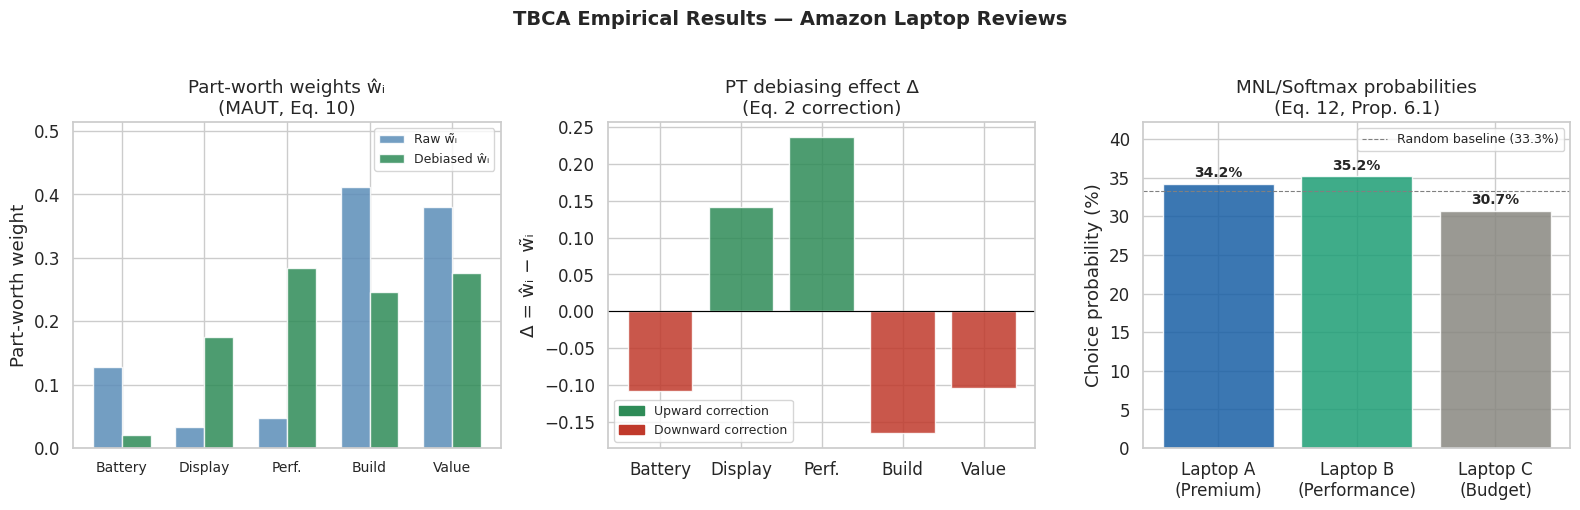

Figures saved: tbca_results.pdf / .png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TBCA Empirical Results — Amazon Laptop Reviews',
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Part-worth weights comparison ─────────────────────────────────
ax1 = axes[0]
x = np.arange(len(ATTRIBUTES))
w = 0.35
bars_raw    = ax1.bar(x - w/2, w_raw_norm,    w, label='Raw w̃ᵢ',      color='#5B8DB8', alpha=0.85)
bars_debias = ax1.bar(x + w/2, w_debias_norm, w, label='Debiased ŵᵢ', color='#2E8B57', alpha=0.85)

ax1.set_xticks(x)
short_labels = ['Battery', 'Display', 'Perf.', 'Build', 'Value']
ax1.set_xticklabels(short_labels, fontsize=10)
ax1.set_ylabel('Part-worth weight')
ax1.set_title('Part-worth weights ŵᵢ\n(MAUT, Eq. 10)')
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(w_raw_norm.max(), w_debias_norm.max()) * 1.25)

# ── Plot 2: PT debiasing delta ─────────────────────────────────────────────
ax2 = axes[1]
deltas = w_debias_norm - w_raw_norm
colors = ['#2E8B57' if d > 0 else '#C0392B' for d in deltas]
ax2.bar(short_labels, deltas, color=colors, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('PT debiasing effect Δ\n(Eq. 2 correction)')
ax2.set_ylabel('Δ = ŵᵢ − w̃ᵢ')
up_patch   = mpatches.Patch(color='#2E8B57', label='Upward correction')
down_patch = mpatches.Patch(color='#C0392B', label='Downward correction')
ax2.legend(handles=[up_patch, down_patch], fontsize=9)

# ── Plot 3: Softmax choice probabilities ──────────────────────────────────
ax3 = axes[2]
alt_labels = ['Laptop A\n(Premium)', 'Laptop B\n(Performance)', 'Laptop C\n(Budget)']
bar_colors = ['#185FA5', '#1D9E75', '#888780']
bars = ax3.bar(alt_labels, P * 100, color=bar_colors, alpha=0.85)

for bar, pval in zip(bars, P):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{pval*100:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_ylabel('Choice probability (%)')
ax3.set_title('MNL/Softmax probabilities\n(Eq. 12, Prop. 6.1)')
ax3.set_ylim(0, max(P * 100) * 1.2)
ax3.axhline(100/3, color='gray', linestyle='--', linewidth=0.8,
            label='Random baseline (33.3%)')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/tbca_results.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/content/tbca_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figures saved: tbca_results.pdf / .png')

# **Cell 11 — Export results**

Export LaTeX tables ready for copy-paste into paper (tbca_tables.tex),structured results (tbca_results.json), and figures (tbca_results.pdf/png).

In [17]:
import json
from google.colab import files

# ── LaTeX table: part-worth weights ──────────────────────────────────────
latex_pw = """\\begin{table}[ht]
\\centering
\\caption{Part-Worth Utility Weights: Raw vs.\\ PT-Debiased (Real Data)}
\\label{tab:part_worths_empirical}
\\begin{tabular}{lrrr}
\\toprule
Attribute & Raw $\\tilde{w}_i$ & Debiased $\\hat{w}_i$ & $\\Delta$ \\\\
\\midrule
"""
for a, wr, wd in zip(ATTRIBUTES, w_raw_norm, w_debias_norm):
    delta = wd - wr
    arrow = '\\uparrow' if delta > 0 else '\\downarrow'
    latex_pw += f"{a.replace('_', ' ').title()} & {wr:.4f} & {wd:.4f} & ${delta:+.4f}\\;{arrow}$ \\\\\n"
latex_pw += f"""\\midrule
$\\Sigma$ & {w_raw_norm.sum():.4f} & {w_debias_norm.sum():.4f} & \\\\
\\midrule
\\multicolumn{{4}}{{l}}{{R\\textsuperscript{{2}} (CV-5): {r2_debias:.4f} (debiased),
{r2_raw:.4f} (raw)}}\\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}"""

# ── LaTeX table: choice probabilities ────────────────────────────────────
latex_choice = """\\begin{table}[ht]
\\centering
\\caption{Softmax Choice Probabilities (MNL/RUM, Eq.~12)}
\\label{tab:choice_probs_empirical}
\\begin{tabular}{lrr}
\\toprule
Alternative & $\\hat{V}_j$ & $P_j$ \\\\
\\midrule
"""
for (name, _), v, p in zip(ALTERNATIVES.items(), V, P):
    latex_choice += f"{name} & {v:.4f} & {p:.4f} \\\\\n"
latex_choice += f"""\\midrule
$\\Sigma$ & & {P.sum():.4f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}"""

# Save
with open('/content/tbca_tables.tex', 'w') as f:
    f.write(latex_pw + '\n\n' + latex_choice)

# JSON results
results = {
    'n_reviews': len(df_sample),
    'n_with_aspects': len(df_features),
    'r2_raw': round(r2_raw, 4),
    'r2_debiased': round(r2_debias, 4),
    'part_worths': {
        a: {'raw': round(float(wr), 4), 'debiased': round(float(wd), 4)}
        for a, wr, wd in zip(ATTRIBUTES, w_raw_norm, w_debias_norm)
    },
    'choice_probabilities': {
        name: {'utility': round(float(v), 4), 'prob': round(float(p), 4)}
        for (name, _), v, p in zip(ALTERNATIVES.items(), V, P)
    }
}
with open('/content/tbca_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Download all output files
for fname in ['tbca_tables.tex', 'tbca_results.json',
              'tbca_results.pdf', 'tbca_results.png']:
    try:
        files.download(f'/content/{fname}')
    except:
        print(f'Could not auto-download {fname} — find it in /content/')

print('\nAll outputs ready.')
print('tbca_tables.tex  → paste directly into paper LaTeX source')
print('tbca_results.pdf → Figure for paper')
print('tbca_results.json → structured results')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All outputs ready.
tbca_tables.tex  → paste directly into paper LaTeX source
tbca_results.pdf → Figure for paper
tbca_results.json → structured results
